In [2]:
%pip install OSMPythonTools osmnx networkx 
%pip install scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from shortest_path import *
origin_point=(48.85341 ,2.3488)
destination_point=(48.83988 ,2.37227)
test=ShortestPath(origin_point,destination_point,0.05)

route=test.dijkstra(traffic_weight=1.5)
test.displayRoute(route)

loading graph


TypeError: ShortestPath.displayRoute() missing 2 required positional arguments: 'travel_time' and 'route'

# A* Grid

loading graph
starting A*


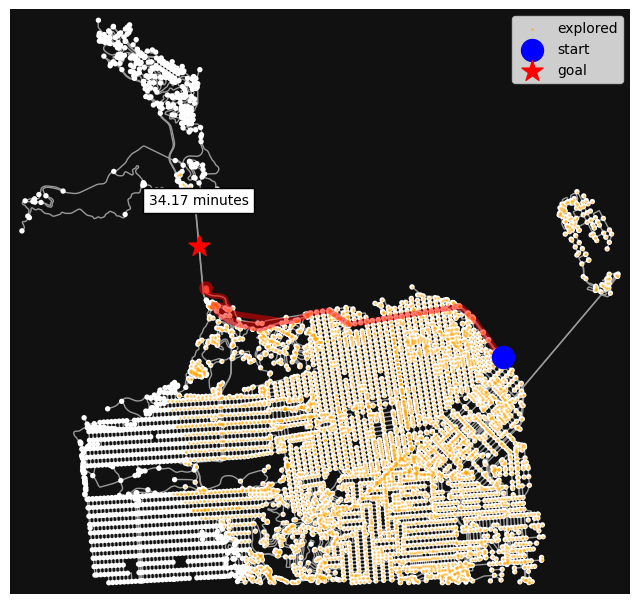

In [ ]:
import osmnx as ox
import networkx as nx
import heapq
import matplotlib.pyplot as plt

orig_point = (37.79555 ,-122.39347)
destination_point = (37.82007 ,-122.47865)

north = max(orig_point[0], destination_point[0])+0.05
south = min(orig_point[0], destination_point[0])-0.05
east = max(orig_point[1], destination_point[1]) + 0.05
west = min(orig_point[1], destination_point[1])-0.05
print("loading graph")
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] *2.5
start_node = ox.nearest_nodes(G, orig_point[1], orig_point[0])

goal_node = ox.nearest_nodes(G, destination_point[1], destination_point[0])

def heuristic(node, goal):
    #euclidean distance heuristic
    y1, x1 = G.nodes[node]['y'], G.nodes[node]['x']
    y2, x2 = G.nodes[goal]['y'], G.nodes[goal]['x']
    return ox.distance.euclidean(y1, x1, y2, x2)


def a_star(graph, start, goal):
    priority_queue = [(0, start)]
    path = {}
    cost = {start: 0}
    explored=set()

    while priority_queue:
        _, current = heapq.heappop(priority_queue)
        explored.add(current)
        #if we reached the goal, add the path
        if current == goal:
            reconstructed_path = []
            while current in path:
                reconstructed_path.append(current)
                current = path[current]
            reconstructed_path.append(start)
            #total time in seconds
            total_time=cost[goal]
            return reconstructed_path,total_time,explored

        # look at road neighbors
        for neighbor in graph.neighbors(current):
            #get the travel time in seconds
            edge_data = graph.get_edge_data(current, neighbor)
            weight = min(d["travel_time"] for d in edge_data.values())

            new_cost = cost[current] + weight
            #if we find a new path or cheaper one, update it
            if neighbor not in cost or new_cost < cost[neighbor]:
                cost[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(priority_queue, (priority, neighbor))
                path[neighbor] = current
    return None,None,explored

print("starting A*")
route,travel_time,explored= a_star(G, start_node, goal_node)
G_undirected=ox.convert.to_undirected(G)

explored_x=[G.nodes[n]["x"] for n in explored]
explored_y=[G.nodes[n]["y"] for n in explored]

fig,ax=ox.plot_graph_route(G_undirected, route,show=False,close=False)

ax.scatter(explored_x,explored_y,c="orange",s=1,alpha=0.4,label="explored")
ax.scatter(orig_point[1], orig_point[0], c="blue",
           s=250, label="start", zorder=5)
ax.scatter(destination_point[1], destination_point[0],
           c="red", s=250, label="goal", zorder=5,marker="*")

ax.annotate(f"{travel_time/60:.2f} minutes", (destination_point[1], destination_point[0]),
            ha="center", textcoords="offset points", xytext=(0, 30),bbox=dict(facecolor="white"))
plt.legend()
plt.show()

In [ ]:
import pygraphviz
G = nx.grid_2d_graph(50, 50)
A = nx.nx_agraph.to_agraph(G)
#label mapping
for u, v, d in G.edges(data=True):
    d['label'] = d.get('travel_time', '')

A.draw("50x50.png", prog="neato")

# Dijkstra

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
#getting origin and destination, making a box around it

orig_point = (37.79555 ,-122.39347)
destination_point = (37.82007 ,-122.47865)

north = max(orig_point[0], destination_point[0])+0.05
south = min(orig_point[0], destination_point[0])-0.05
east = max(orig_point[1], destination_point[1]) + 0.05
west = min(orig_point[1], destination_point[1])-0.05
# left, bottom, right, top box
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")

G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] *2.5

# fixed x and y coordinates for path
orig_node = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])

destination_points = ox.distance.nearest_nodes(
    G, X=destination_point[1], Y=destination_point[0])

def dijkstra(graph, start, end):
    #setting up shortest path, visited set
    shortest_paths = {start: (None, 0)}
    current_node = start
    visited = set()
    #visit the next node and update path
    while current_node != end:
        visited.add(current_node)
        destinations = graph[current_node]
        weight_to_current_node = shortest_paths[current_node][1]

        for next_node in destinations:
            #get weight of the node, 0 is the first edge
            weight = graph[current_node][next_node][0]['travel_time']
            new_weight = weight_to_current_node + weight
            #update the shortest path
            if next_node not in shortest_paths or new_weight < shortest_paths[next_node][1]:
                shortest_paths[next_node] = (current_node, new_weight)

        next_destinations = {node: shortest_paths[node] for node in shortest_paths if node not in visited}

        if not next_destinations:
            return "Route Not Possible"
        #get the shortest path for the node
        current_node = min(next_destinations, key=lambda k: next_destinations[k][1])

    # after the loop, if end in shortest_paths, we found a path
    if end in shortest_paths:
        return shortest_paths[end][1]
    else:
        return "Route Not Possible"

print(f"{dijkstra(G, orig_node, destination_points)/60:.2f} minutes")


KeyboardInterrupt: 

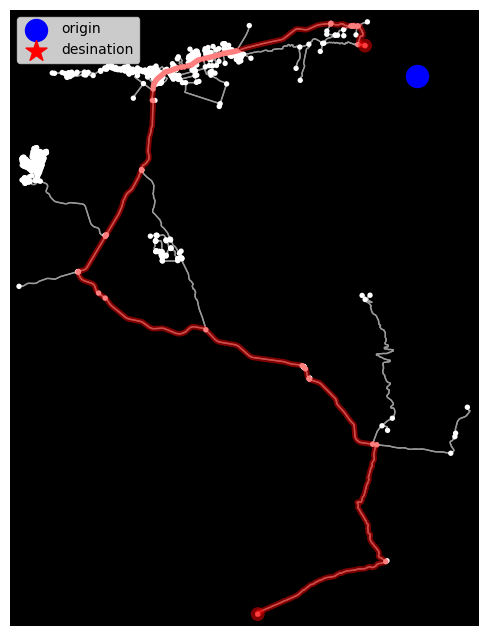

Time 203.75 minutes


In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
#getting orgin and destination, making a box around it

orig_point = (20.02021 ,-155.42455)
destination_point = (19.06045 ,-155.75613)

north = max(orig_point[0], destination_point[0])+0.05
south = min(orig_point[0], destination_point[0])-0.05
east = max(orig_point[1], destination_point[1]) + 0.05
west = min(orig_point[1], destination_point[1])-0.05
# left, bottom, right, top box
# left, bottom, right, top box
# left, bottom, right, top box
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")

G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)


orig_node = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])

destination_points = ox.distance.nearest_nodes(
    G, X=destination_point[1], Y=destination_point[0])


#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] *1.5

route = nx.shortest_path(G, orig_node, destination_points, weight='travel_time')
time = nx.shortest_path_length(
    G, orig_node, destination_points, weight="travel_time")
fig, ax = ox.plot_graph_route(
    G, route, show=False, close=False, bgcolor="black")


ax.scatter(orig_point[1], orig_point[0], c="blue",
           s=250, label="origin", zorder=5)
ax.scatter(destination_point[1], destination_point[0],
           c="red", s=250, label="desination", zorder=5,marker="*")

ax.annotate(f"{time/60:.2f} minutes", (destination_point[1], destination_point[0]),
            ha="center", textcoords="offset points", xytext=(0, 30),bbox=dict(facecolor="white"))

plt.legend()
plt.show()
print(f'Time {time/60:.2f} minutes')

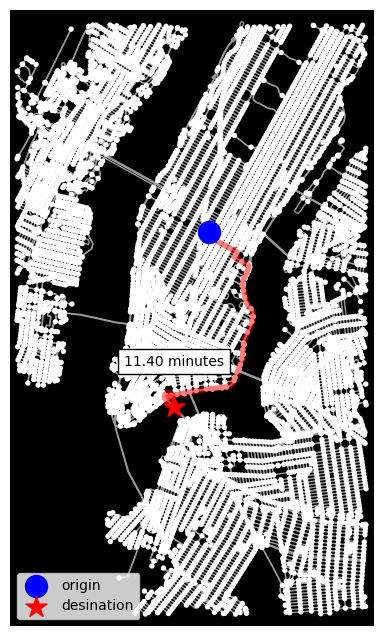

Time 11.40 minutes


In [ ]:

#empire state building
orig_point=(40.7484, -73.9857)
#brooklyn bridge
destination_point=(40.7061, -73.9969)
north = max(orig_point[0], destination_point[0])+0.05
south = min(orig_point[0], destination_point[0])-0.05
east = max(orig_point[1], destination_point[1]) + 0.05
west = min(orig_point[1], destination_point[1])-0.05
# left, bottom, right, top box
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")
#hwy_speeds={"residential":20,"seconday":30,"tertiary":40}
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# fixed x and y coordinates for path
# change background color to white
orig_node = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])

destination_points = ox.distance.nearest_nodes(
    G, X=destination_point[1], Y=destination_point[0])


#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] * 1.6

route = nx.shortest_path(G, orig_node, destination_points, weight='travel_time')
time = nx.shortest_path_length(
    G, orig_node, destination_points, weight="travel_time")
fig, ax = ox.plot_graph_route(
    G, route, show=False, close=False, bgcolor="black")


ax.scatter(orig_point[1], orig_point[0], c="blue",
           s=250, label="origin", zorder=5)
ax.scatter(destination_point[1], destination_point[0],
           c="red", s=250, label="desination", zorder=5,marker="*")

ax.annotate(f"{time/60:.2f} minutes", (destination_point[1], destination_point[0]),
            ha="center", textcoords="offset points", xytext=(0, 30),bbox=dict(facecolor="white"))

plt.legend()
plt.show()
print(f'Time {time/60:.2f} minutes')


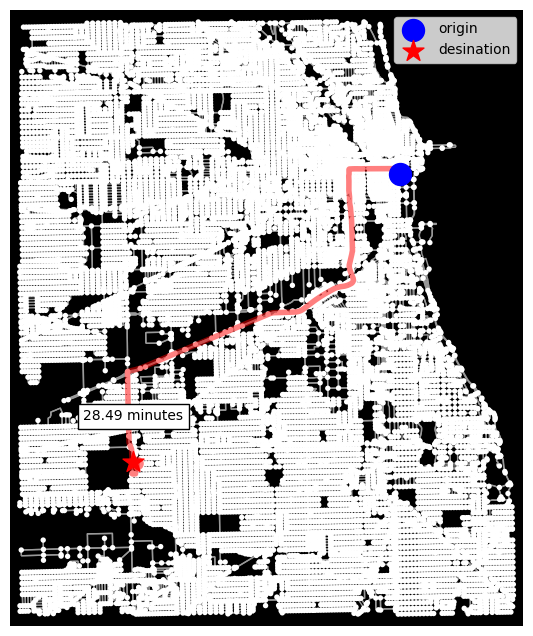

Time 28.49 minutes


In [ ]:

#cloud gate (bean) coordinates
orig_point=(41.8827, -87.6233)
#midway airport
destination_point=(41.78819, -87.74095)
north = max(orig_point[0], destination_point[0])+0.05
south = min(orig_point[0], destination_point[0])-0.05
east = max(orig_point[1], destination_point[1]) + 0.05
west = min(orig_point[1], destination_point[1])-0.05
# left, bottom, right, top box
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")
#hwy_speeds={"residential":20,"seconday":30,"tertiary":40}
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# fixed x and y coordinates for path
# change background color to white
orig_node = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])

destination_points = ox.distance.nearest_nodes(
    G, X=destination_point[1], Y=destination_point[0])


#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] * 1.6

route = nx.shortest_path(G, orig_node, destination_points, weight='travel_time')
time = nx.shortest_path_length(
    G, orig_node, destination_points, weight="travel_time")
fig, ax = ox.plot_graph_route(
    G, route, show=False, close=False, bgcolor="black")


ax.scatter(orig_point[1], orig_point[0], c="blue",
           s=250, label="origin", zorder=5)
ax.scatter(destination_point[1], destination_point[0],
           c="red", s=250, label="desination", zorder=5,marker="*")

ax.annotate(f"{time/60:.2f} minutes", (destination_point[1], destination_point[0]),
            ha="center", textcoords="offset points", xytext=(0, 30),bbox=dict(facecolor="white"))

plt.legend()
plt.show()
print(f'Time {time/60:.2f} minutes')

In [ ]:

#san francisco
orig_point=(37.78794 -122.40752)
#new york
destination_point=(40.71273 -74.00602)
place_name="United States"
G=ox.graph_from_place(place_name,network_type='drive')
#fixed x and y coordinates for path
orig_node=ox.distance.nearest_nodes(G,X=orig_point[1],Y=orig_point[0])

destination_points=ox.distance.nearest_nodes(G,X=destination_point[1],Y=destination_point[0])


route=nx.shortest_path(G,orig_node,destination_points,weight='length')
fig, ax = ox.plot_graph_route(G, route,show=False,close=False,bgcolor="dimgray")
ax.scatter(orig_point[1],orig_point[0],c="blue",s=100,label="start",zorder=5)
ax.scatter(destination_point[1],destination_point[0],c="red",s=100,label="end",zorder=5)

plt.annotate("origin",(orig_point[1],orig_point[0]),ha="center",textcoords="offset points",xytext=(0,10))
plt.annotate("destination",(destination_point[1],destination_point[0]),ha="center",textcoords="offset points",xytext=(0,10))
plt.show()


/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 126,975 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 150 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


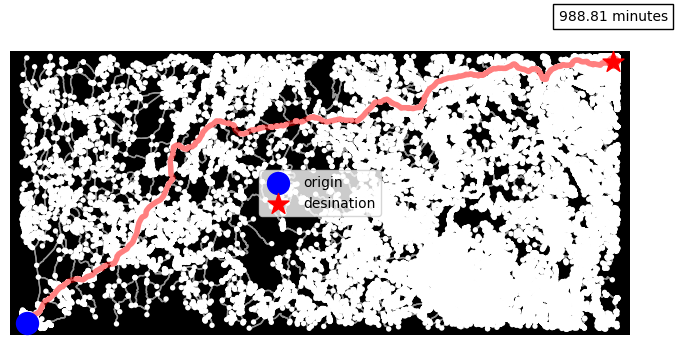

Time 988.81 minutes


In [ ]:



orig_point=(36.16743, -115.14841)

destination_point=(39.73924, -104.98486)
north = max(orig_point[0], destination_point[0])+0.08
south = min(orig_point[0], destination_point[0])-0.08
east = max(orig_point[1], destination_point[1]) + 0.08
west = min(orig_point[1], destination_point[1])-0.08
# left, bottom, right, top box
G = ox.graph_from_bbox(bbox=(west, south, east, north), network_type="drive")
#hwy_speeds={"residential":20,"seconday":30,"tertiary":40}
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# fixed x and y coordinates for path
# change background color to white
orig_node = ox.distance.nearest_nodes(G, X=orig_point[1], Y=orig_point[0])

destination_points = ox.distance.nearest_nodes(
    G, X=destination_point[1], Y=destination_point[0])


#traffic travel time
for u, v, k, data in G.edges(data=True, keys=True):
    data['travel_time'] = data['travel_time'] * 1.6

route = nx.shortest_path(G, orig_node, destination_points, weight='travel_time')
time = nx.shortest_path_length(
    G, orig_node, destination_points, weight="travel_time")
fig, ax = ox.plot_graph_route(
    G, route, show=False, close=False, bgcolor="black")


ax.scatter(orig_point[1], orig_point[0], c="blue",
           s=250, label="origin", zorder=5)
ax.scatter(destination_point[1], destination_point[0],
           c="red", s=250, label="desination", zorder=5,marker="*")

ax.annotate(f"{time/60:.2f} minutes", (destination_point[1], destination_point[0]),
            ha="center", textcoords="offset points", xytext=(0, 30),bbox=dict(facecolor="white"))

plt.legend()
plt.show()
print(f'Time {time/60:.2f} minutes')

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import networkx as nx
place_name="Lincoln, Nebraska"
area=ox.geocode_to_gdf(place_name)
tags={'building':True}
buildings=ox.features_from_place(place_name,tags)
buildings.head()

